#  Prediksi Risiko Penyakit Jantung dengan Metode Ensemble SVM

Penelitian pada notebook ini membangun dan membandingkan model:
- **Baseline**: SVM standar dengan 4 kernel
- **Usulan Akhir**: Ensemble SVM dengan **Poly** sebagai Meta Kernel dan 2 kernel pada base kernel yaitu **Sigmoid** dan **RBF**

---
###  Alur Kerja
| Tahap | Deskripsi |
|---|---|
| 1 | Import Library |
| 2 | Load Data|
| 3 | Preprocessing (Splitting Data, Scaling Data) |
| 4 | Model Baseline (SVM Standar) |
| 5 | Model Ensemble SVM (Meta: Poly, Base: Sigmoid dan RBF) |
| 6 | Perbandingan Keempat Model |
| 7 | Prediksi Pasien Penyakit Jantung|
| 8 | Analisis Waktu Komputasi|
| 9 | Kesimpulan|

## Import Library


Pada tahap ini dilakukan inisialisasi beberapa library yang digunakan dalam penelitian untuk proses pengolahan data, preprocessing, pemodelan machine learning, evaluasi model, dan visualisasi data. Library `pandas` dan `numpy` digunakan untuk manipulasi data, `StandardScaler` untuk standarisasi data, `SVC` dan `StackingClassifier` untuk proses klasifikasi, serta `sklearn.metrics` untuk evaluasi performa model. Selain itu, `matplotlib` dan `seaborn` digunakan untuk visualisasi data. Dataset kemudian diakses dari Google Drive dan dibaca menggunakan `read_csv()` ke dalam variabel `df`.


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('Cardiovascular_Disease_Dataset.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

Load data merupakan proses membaca dan memuat dataset dari sumber penyimpanan ke dalam program agar dapat digunakan pada tahap analisis, preprocessing, dan pemodelan. Pada penelitian ini, dataset dibaca menggunakan fungsi `read_csv()` dari library `pandas` dan disimpan ke dalam variabel `df`.


In [2]:
df.head(10)

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1
5,148462,24,1,1,173,0,0,0,161,0,4.7,3,2,1
6,168686,79,1,2,130,240,0,2,157,0,2.5,2,1,1
7,170498,52,1,0,127,345,0,0,192,1,4.9,1,0,0
8,188225,62,1,0,121,357,0,1,138,0,2.8,0,0,0
9,192523,61,0,0,190,181,0,1,150,0,2.9,2,0,1


## Pre-processing

Tahap preprocessing dilakukan untuk memastikan data siap digunakan dalam proses pemodelan machine learning. Berdasarkan hasil `df.info()` dan `df.describe()`, dataset tidak memiliki missing value, tipe data sudah sesuai, dan tidak ditemukan permasalahan signifikan pada data. Selanjutnya dilakukan pengecekan distribusi kelas pada variabel target menggunakan `value_counts()` untuk mengetahui jumlah data pada masing-masing kelas.

Pada tahap preprocessing juga dilakukan penghapusan atribut patientid menggunakan `drop()` karena atribut tersebut hanya berfungsi sebagai identitas pasien dan tidak berpengaruh terhadap proses klasifikasi. Setelah itu, dataset dipisahkan menjadi variabel fitur (X) dan variabel target (y). Selanjutnya dilakukan standarisasi data menggunakan StandardScaler agar setiap fitur memiliki skala yang seimbang sehingga dapat membantu meningkatkan performa model klasifikasi.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [4]:
df['target'].value_counts()

,count
target,
1,580
0,420


In [5]:
df.drop(columns=['patientid'], inplace=True)
X = df.drop(columns=['target'])
y = df['target']
df

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,31,1,1,199,0,0,2,136,0,5.3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,48,1,2,139,349,0,2,183,1,5.6,2,2,1
996,47,1,3,143,258,1,1,98,1,5.7,1,0,0
997,69,1,0,156,434,1,0,196,0,1.4,3,1,1
998,45,1,1,186,417,0,1,117,1,5.9,3,2,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   gender             1000 non-null   int64  
 2   chestpain          1000 non-null   int64  
 3   restingBP          1000 non-null   int64  
 4   serumcholestrol    1000 non-null   int64  
 5   fastingbloodsugar  1000 non-null   int64  
 6   restingrelectro    1000 non-null   int64  
 7   maxheartrate       1000 non-null   int64  
 8   exerciseangia      1000 non-null   int64  
 9   oldpeak            1000 non-null   float64
 10  slope              1000 non-null   int64  
 11  noofmajorvessels   1000 non-null   int64  
 12  target             1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 101.7 KB


### Splitting Data and Scalling Data

In [7]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

print ("Shape of Train Data:", X_train.shape)# menampilkan shape dari train data
print ("Shape of Test Data:", X_test.shape) # menampilkan shape dari test data

Shape of Train Data: (800, 12)
Shape of Test Data: (200, 12)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
df

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,31,1,1,199,0,0,2,136,0,5.3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,48,1,2,139,349,0,2,183,1,5.6,2,2,1
996,47,1,3,143,258,1,1,98,1,5.7,1,0,0
997,69,1,0,156,434,1,0,196,0,1.4,3,1,1
998,45,1,1,186,417,0,1,117,1,5.9,3,2,1


In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['0', '1'], yticklabels=['0', '1'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

## SVM Standar (Linear, Sigmoid, RBF, Poly)

Support Vector Machine (SVM) merupakan algoritma machine learning yang digunakan untuk tugas klasifikasi dengan mencari hyperplane terbaik yang dapat memisahkan data antar kelas. Pada penelitian ini digunakan beberapa jenis kernel SVM, yaitu Linear, Sigmoid, Radial Basis Function (RBF), dan Polynomial (Poly). Setiap kernel memiliki karakteristik berbeda dalam memetakan data.

### SVM Kernel Linear

Kernel Linear digunakan ketika data dapat dipisahkan secara linear. Kernel ini bekerja dengan mencari garis atau hyperplane terbaik untuk memisahkan kelas data secara langsung tanpa transformasi tambahan.

SVM Linear Accuracy: 0.97
Presisi: 0.9626
Recall: 0.9810
F1-Score: 0.9717

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        95
           1       0.96      0.98      0.97       105

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

confusion Matrix


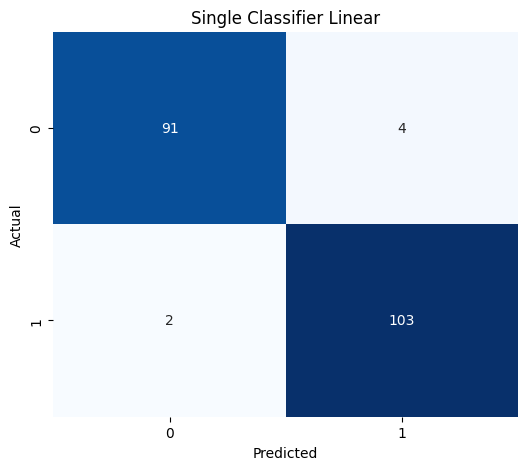

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_linear_base = SVC(kernel='linear', probability=True, random_state=42)

# Linear
svm_linear_base.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear_base.predict(X_test_scaled)

print("SVM Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print(f"Presisi: {precision_score(y_test, y_pred_linear):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_linear):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_linear):.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_linear))
print("confusion Matrix")
plot_confusion_matrix(y_test, y_pred_linear, "Single Classifier Linear")

### SVM Kernel RBF

Kernel RBF merupakan kernel yang paling umum digunakan pada SVM karena mampu menangani data non-linear dengan baik. Kernel ini memetakan data ke dimensi yang lebih tinggi sehingga pemisahan antar kelas menjadi lebih optimal.

SVM RBF Accuracy: 0.975
Presisi: 0.9630
Recall: 0.9905
F1-Score: 0.9765

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97        95
           1       0.96      0.99      0.98       105

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200

Confusion Matrix


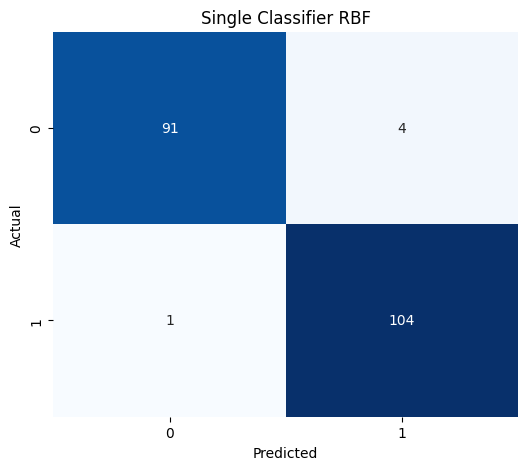

In [11]:
svm_rbf_base    = SVC(kernel='rbf', probability=True, random_state=42)

# RBF
svm_rbf_base.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf_base.predict(X_test_scaled)

print("SVM RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(f"Presisi: {precision_score(y_test, y_pred_rbf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rbf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rbf):.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rbf))
print("Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_rbf, "Single Classifier RBF")

### SVM Kernel Polynomial

Kernel Polynomial digunakan untuk memodelkan hubungan data yang kompleks dengan membentuk batas keputusan berbentuk polinomial. Kernel ini cocok digunakan ketika pola data tidak dapat dipisahkan secara linear sederhan

SVM Poly Accuracy: 0.965
Presisi: 0.9537
Recall: 0.9810
F1-Score: 0.9671

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        95
           1       0.95      0.98      0.97       105

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200

Confusion Matrix


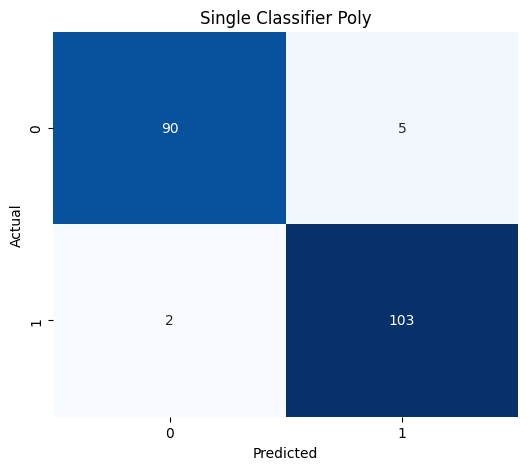

In [12]:
svm_poly_base   = SVC(kernel='poly', probability=True, random_state=42)

# Poly
svm_poly_base.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly_base.predict(X_test_scaled)

print("SVM Poly Accuracy:", accuracy_score(y_test, y_pred_poly))
print(f"Presisi: {precision_score(y_test, y_pred_poly):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_poly):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_poly):.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_poly))
print("Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_poly, "Single Classifier Poly")

### SVM Kernel Sigmoid

Kernel Sigmoid bekerja menyerupai fungsi aktivasi pada Artificial Neural Network (ANN). Kernel ini digunakan untuk menangani hubungan data yang bersifat non-linear.

SVM Sigmoid Accuracy: 0.955
Presisi: 0.9364
Recall: 0.9810
F1-Score: 0.9581

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        95
           1       0.94      0.98      0.96       105

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200

Confusion Matrix


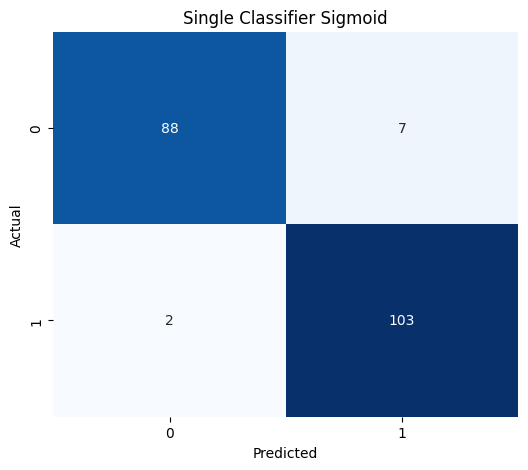

In [13]:
svm_sigmoid_base = SVC(kernel='sigmoid', probability=True, random_state=42)

# Sigmoid
svm_sigmoid_base.fit(X_train_scaled, y_train)
y_pred_sigmoid = svm_sigmoid_base.predict(X_test_scaled)

print("SVM Sigmoid Accuracy:", accuracy_score(y_test, y_pred_sigmoid))
print(f"Presisi: {precision_score(y_test, y_pred_sigmoid):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_sigmoid):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_sigmoid):.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_sigmoid))
print("Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_sigmoid, "Single Classifier Sigmoid")

## Ensemble SVM

Ensemble SVM merupakan metode klasifikasi yang menggabungkan beberapa model Support Vector Machine (SVM) untuk meningkatkan performa prediksi dibandingkan menggunakan satu model saja. Pendekatan ensemble bekerja dengan memanfaatkan kombinasi hasil prediksi dari beberapa model tunggal agar menghasilkan keputusan yang lebih stabil, akurat, dan robust.

Pada penelitian ini, ensemble SVM dibangun menggunakan beberapa kernel SVM, yaitu Linear, Sigmoid, RBF, dan Polynomial (Poly). Setiap kernel memiliki karakteristik berbeda dalam mempelajari pola data, sehingga kombinasi beberapa kernel dapat membantu model menangkap hubungan data secara lebih optimal.

Metode ensemble yang digunakan adalah `StackingClassifier`, di mana beberapa model SVM dijadikan sebagai base learner. Hasil prediksi dari masing-masing model kemudian digabungkan dan diproses kembali oleh model meta learner untuk menghasilkan prediksi akhir.

Penggunaan ensemble SVM bertujuan untuk:

* meningkatkan akurasi klasifikasi,
* mengurangi kesalahan prediksi,
* meningkatkan kemampuan generalisasi model,
* serta memanfaatkan kelebihan dari masing-masing kernel SVM.





Stacking (meta:Poly ; base: Sigmoid, RBF): 0.98
Presisi: 0.9810
Recall: 0.9810
F1-Score: 0.9810

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        95
           1       0.98      0.98      0.98       105

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

Confusion Matrix


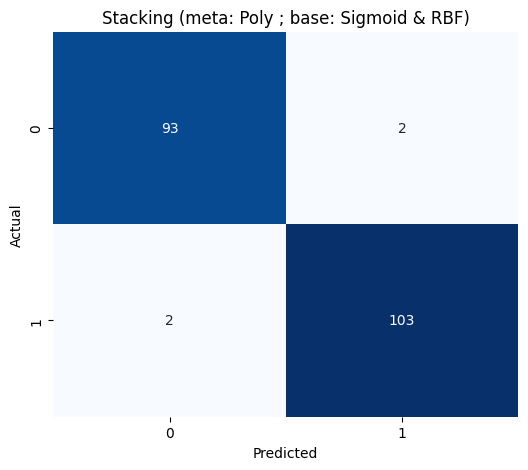

In [14]:
meta_model = SVC(kernel='poly', probability=True)

stacking = StackingClassifier(
    estimators=[
        ('svm_rbf', svm_rbf_base),
        ('svm_sigmoid', svm_sigmoid_base)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    cv=5
)

stacking.fit(X_train_scaled, y_train)

y_pred_stack = stacking.predict(X_test_scaled)

print("\nStacking (meta:Poly ; base: Sigmoid, RBF):",
      accuracy_score(y_test, y_pred_stack))
print(f"Presisi: {precision_score(y_test, y_pred_stack):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_stack):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_stack):.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_stack))
print("Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_stack, "Stacking (meta: Poly ; base: Sigmoid & RBF)")

## Perbandingan 4 Model

Berdasarkan beberapa penelitian yang telah dilakukan, kombinasi kernel yang memberikan performa terbaik adalah penggunaan kernel `Sigmoid` dan `RBF` sebagai *base learner*, serta kernel `Polynomial` (Poly) sebagai *meta learner*. Kombinasi tersebut dinilai mampu meningkatkan akurasi klasifikasi karena kernel Sigmoid dan RBF efektif dalam menangkap pola `non-linear` pada data, sedangkan kernel Poly mampu mengoptimalkan proses penggabungan hasil prediksi dari model dasar.

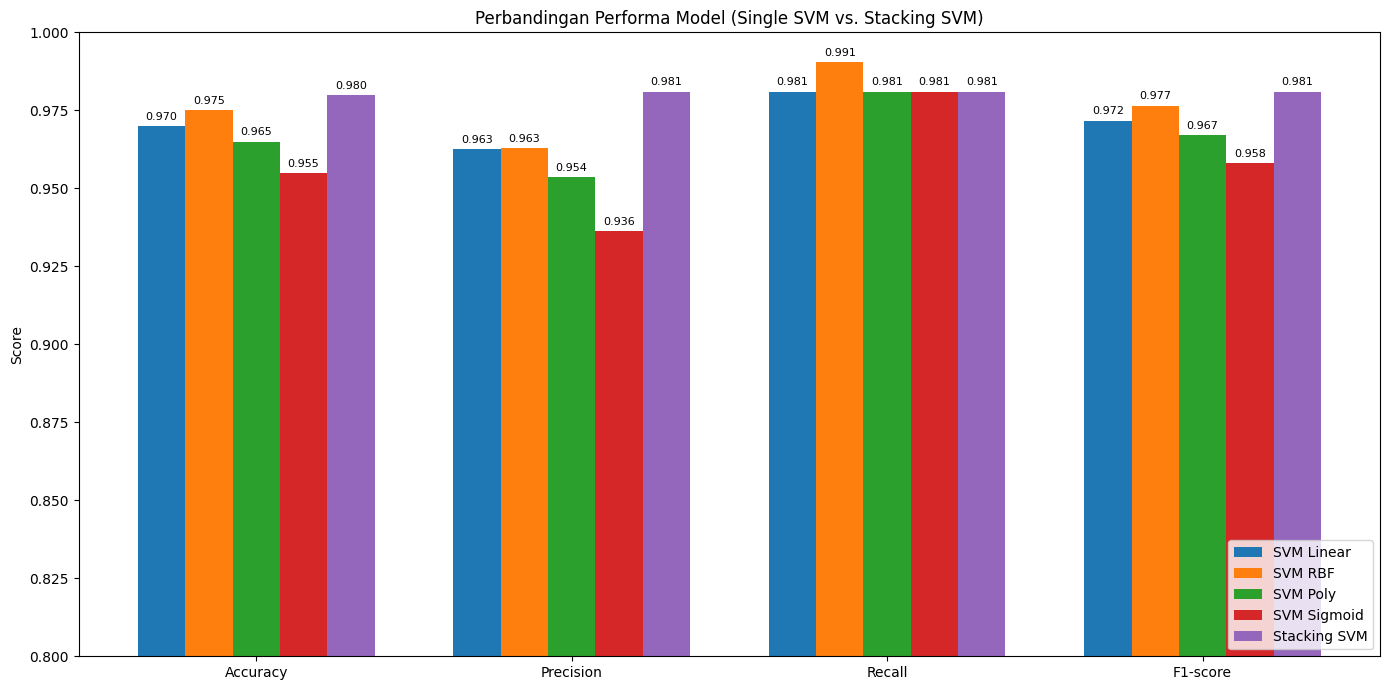

In [15]:
# Metrics names
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Scores for each model (extracted from previous cell outputs)
single_linear = [0.97, 0.9626, 0.9810, 0.9717]
single_rbf = [0.975, 0.9630, 0.9905, 0.9765]
single_poly = [0.965, 0.9537, 0.9810, 0.9671]
single_sigmoid = [0.955, 0.9364, 0.9810, 0.9581]
stacking_model = [0.98, 0.9810, 0.9810, 0.9810]

# Number of models to compare
num_models = 5

# X-axis positions for the bars
x = np.arange(len(metrics))
width = 0.15 # Width of each bar

fig, ax = plt.subplots(figsize=(14, 7))

# Plotting bars for each model
rects1 = ax.bar(x - 2*width, single_linear, width, label='SVM Linear')
rects2 = ax.bar(x - width, single_rbf, width, label='SVM RBF')
rects3 = ax.bar(x, single_poly, width, label='SVM Poly')
rects4 = ax.bar(x + width, single_sigmoid, width, label='SVM Sigmoid')
rects5 = ax.bar(x + 2*width, stacking_model, width, label='Stacking SVM')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model (Single SVM vs. Stacking SVM)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.80, 1.00)
ax.legend(loc='lower right')

# Function to add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)

plt.tight_layout()
plt.show()

## Prediksi Pasien Penyakit Jantung

Berdasarkan output prediksi yang dihasilkan, model `Ensemble SVM` mampu mengklasifikasikan kondisi pasien ke dalam kategori menderita penyakit jantung maupun tidak menderita penyakit jantung. Pada hasil prediksi, pasien 1 terdeteksi positif menderita penyakit jantung, sedangkan pasien 2 diprediksi tidak menderita penyakit jantung. Hasil tersebut menunjukkan bahwa model yang dibangun dapat digunakan untuk membantu mendeteksi kemungkinan penyakit jantung berdasarkan data kesehatan pasien yang diberikan.




In [16]:
def interpret_prediction(model, scaler, new_data):
    new_data_scaled = scaler.transform(new_data)
    prediction = model.predict(new_data_scaled)

    if prediction[0] == 1:
        return "Pasien positif menderita penyakit jantung."
    else:
        return "Pasien tidak menderita penyakit jantung."

# Contoh 1: Pasien dengan ciri-ciri cenderung positif penyakit jantung (data yang sama dengan sebelumnya)
new_patient_positive = pd.DataFrame([[53, 1, 2, 171, 0, 0, 1, 147, 0, 5.3, 3, 3]],
                           columns=['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels'])
print("Prediksi untuk pasien 1:")
print(interpret_prediction(stacking, scaler, new_patient_positive))

# Contoh 2: Pasien dengan ciri-ciri cenderung negatif penyakit jantung (contoh data)
# Menggunakan nilai-nilai yang umumnya terkait dengan risiko rendah (e.g., usia muda, tidak ada nyeri dada, kolesterol normal, tidak ada exercise induced angina)
new_patient_negative = pd.DataFrame([[30, 0, 0, 120, 180, 0, 0, 150, 0, 0.5, 1, 0]],
                           columns=['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels'])
print("\nPrediksi untuk pasien 2:")
print(interpret_prediction(stacking, scaler, new_patient_negative))

Prediksi untuk pasien 1:
Pasien positif menderita penyakit jantung.

Prediksi untuk pasien 2:
Pasien tidak menderita penyakit jantung.


In [17]:
def interpret_target(target):
    if target == 0:
        return "Pasien tidak menderita penyakit jantung."
    elif target == 1:
        return "Pasien positif menderita penyakit jantung."
    else:
        return "Label tidak valid."
print(interpret_target(0))
print(interpret_target(1))


Pasien tidak menderita penyakit jantung.
Pasien positif menderita penyakit jantung.


## Analisis Waktu Komputasi

Waktu komputasi pada metode Ensemble SVM cenderung lebih lama dibandingkan model SVM tunggal karena proses pelatihan dan prediksi dilakukan menggunakan beberapa model secara bersamaan. Pada metode ensemble, setiap *base learner* seperti kernel Sigmoid dan RBF harus dilatih terlebih dahulu, kemudian hasil prediksi dari masing-masing model diproses kembali oleh *meta learner* kernel Polynomial (Poly) untuk menghasilkan prediksi akhir.

Berbeda dengan model SVM tunggal yang hanya melibatkan satu proses pelatihan dan satu proses prediksi, metode ensemble memiliki tahapan komputasi tambahan sehingga membutuhkan waktu eksekusi, penggunaan memori, dan sumber daya komputasi yang lebih besar.


In [18]:
import time
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

# Dictionary untuk menyimpan hasil waktu
results_time = {}
# =========================
# SINGLE SVM (PER KERNEL)
# =========================\
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for kernel in kernels:
    model = SVC(kernel=kernel, probability=True, random_state=42)
    # Training time
    start_train = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    end_train = time.perf_counter()

    train_time = end_train - start_train

    # Prediction time
    start_pred = time.perf_counter()
    model.predict(X_test_scaled)
    end_pred = time.perf_counter()

    pred_time = end_pred - start_pred

    results_time[f"Single SVM ({kernel})"] = {
        "Training Time": train_time,
        "Prediction Time": pred_time
    }
# =========================
# STACKING MODEL
# =========================

meta_model = SVC(kernel='poly', probability=True, random_state=42)

stacking_model = StackingClassifier(
    estimators=[
        ('svm_rbf', SVC(kernel='rbf', probability=True, random_state=42)),
        ('svm_sigmoid', SVC(kernel='sigmoid', probability=True, random_state=42))
    ],
    final_estimator=meta_model,
    cv=5
)

# Training time stacking
start_train = time.perf_counter()
stacking_model.fit(X_train_scaled, y_train)
end_train = time.perf_counter()

stack_train_time = end_train - start_train

# Prediction time stacking
start_pred = time.perf_counter()
stacking_model.predict(X_test_scaled)
end_pred = time.perf_counter()

stack_pred_time = end_pred - start_pred

results_time["Stacking SVM"] = {
    "Training Time": stack_train_time,
    "Prediction Time": stack_pred_time
}

# =========================
# PRINT HASIL
# =========================

print("\n===== HASIL WAKTU KOMPUTASI =====\n")

for model_name, times in results_time.items():
    print(f"{model_name}")
    print(f"  Training Time  : {times['Training Time']:.6f} detik")
    print(f"  Prediction Time: {times['Prediction Time']:.6f} detik\n")



===== HASIL WAKTU KOMPUTASI =====

Single SVM (linear)
  Training Time  : 0.099058 detik
  Prediction Time: 0.001534 detik

Single SVM (rbf)
  Training Time  : 0.083058 detik
  Prediction Time: 0.008654 detik

Single SVM (poly)
  Training Time  : 0.149618 detik
  Prediction Time: 0.018158 detik

Single SVM (sigmoid)
  Training Time  : 0.183069 detik
  Prediction Time: 0.007383 detik

Stacking SVM
  Training Time  : 1.141637 detik
  Prediction Time: 0.010092 detik



**THE END**

## Kesimpulan
1. Hasil penelitian menunjukkan bahwa metode ensemble Support Vector Machine (SVM)
dengan berbgai kombinasi dari empat jenis kernel utama SVM, yaitu linear, Radial Basis
Function (RBF), Polynomial, dan Sigmoid, menunjukkan bahwa kernel non-linear secara
umum memiliki kemampuan yang lebih baik dibandingkan kernel linear.
2. Pada penerapan metode ensemble stacking SVM dengan kombinasi dua, tiga, dan
empat kernel menunjukkan penambahan jumlah kernel tidak selalu meningkatkan
performa model.
3. Model terbaik pada penelitian ini diperoleh dari stacking dua kernel, dengan kernel
Polynomial sebagai meta model serta kernel RBF dan Sigmoid sebagai base model.
Model tersebut memberikan performa terbaik dan paling efisien dibandingkan dengan
stacking tiga atau empat kernel.
4. Penggunaan kernel Polynomial sebagai meta model memberikan performa yang paling
konsisten dan stabil dalam berbagai kombinasi kernel, karena mampu menangkap
hubungan non-linear antar prediksi base model secara efektif.
5. Pemilihan kombinasi kernel yang tepat lebih berpengaruh dibandingkan dengan jumlah
kernel yang digunakan.
6. Dari sisi komputasi, model stacking membutuhkan waktu pelatihan dan prediksi yang
lebih lama jika dibandingkan dengan model SVM tunggal karena melibatkan beberapa
55
penggabungan base model dan meta model. Meskipun demikian, selisih waktu
komputasi masih berada dalam batas yang wajar.
7. Jika fokus terhadap efisiensi komputasi, single model SVM dengan kernel RBF akan lebih
jauh menguntungkan. Jika fokus pada eksplorasi metode, stabilitas klasifikasi, ensemble
stacking akan menjadi pilihan terbaik karena generalisasi yang lebih baik.

In [21]:
!pip install -r requirements.txt